In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
trades = pd.read_csv('/content/historical_data.csv')
sentiment = pd.read_csv('/content/fear_greed_index.csv')
print("Historical Data Shape:", trades.shape)
print("Fear & Greed Shape:", sentiment.shape)

Historical Data Shape: (211224, 16)
Fear & Greed Shape: (2644, 4)


In [3]:
trades.head()
trades.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [4]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [5]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [6]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [7]:
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True
)
sentiment['date'] = pd.to_datetime(
    sentiment['date']
)
trades['Date'] = trades['Timestamp IST'].dt.date
sentiment['Date'] = sentiment['date'].dt.date
print(trades[['Timestamp IST','Date']].head())
print(sentiment[['date','Date']].head())

        Timestamp IST        Date
0 2024-12-02 22:50:00  2024-12-02
1 2024-12-02 22:50:00  2024-12-02
2 2024-12-02 22:50:00  2024-12-02
3 2024-12-02 22:50:00  2024-12-02
4 2024-12-02 22:50:00  2024-12-02
        date        Date
0 2018-02-01  2018-02-01
1 2018-02-02  2018-02-02
2 2018-02-03  2018-02-03
3 2018-02-04  2018-02-04
4 2018-02-05  2018-02-05


In [8]:
print("Trader Data Range")
print(trades['Date'].min())
print(trades['Date'].max())
print("\nSentiment Data Range")
print(sentiment['Date'].min())
print(sentiment['Date'].max())

Trader Data Range
2023-05-01
2025-05-01

Sentiment Data Range
2018-02-01
2025-05-02


In [9]:
df = pd.merge(
    trades,
    sentiment[['Date', 'classification', 'value']],
    on='Date',
    how='left'
)
print(df.shape)
df.head()

(211224, 19)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0


In [10]:
print(df['classification'].isnull().sum())

6


In [11]:
df = df.dropna(subset=['classification'])
print("Remaining rows:", len(df))

Remaining rows: 211218


In [12]:
print(df['classification'].isnull().sum())

0


classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


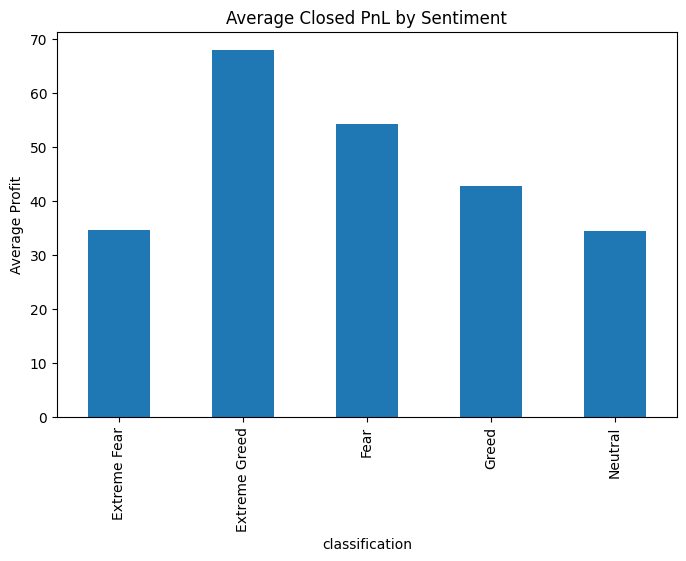

In [16]:
import os

profit_by_sentiment = df.groupby(
    'classification'
)['Closed PnL'].mean()

print(profit_by_sentiment)

profit_by_sentiment.plot(
    kind='bar',
    figsize=(8,5)
)
plt.title("Average Closed PnL by Sentiment")
plt.ylabel("Average Profit")
output_dir = '../images'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

plt.savefig(os.path.join(output_dir, 'average_profit_sentiment.png'), bbox_inches='tight')
plt.show()

classification
Extreme Fear     7.391102e+05
Extreme Greed    2.715171e+06
Fear             3.357155e+06
Greed            2.150129e+06
Neutral          1.292921e+06
Name: Closed PnL, dtype: float64


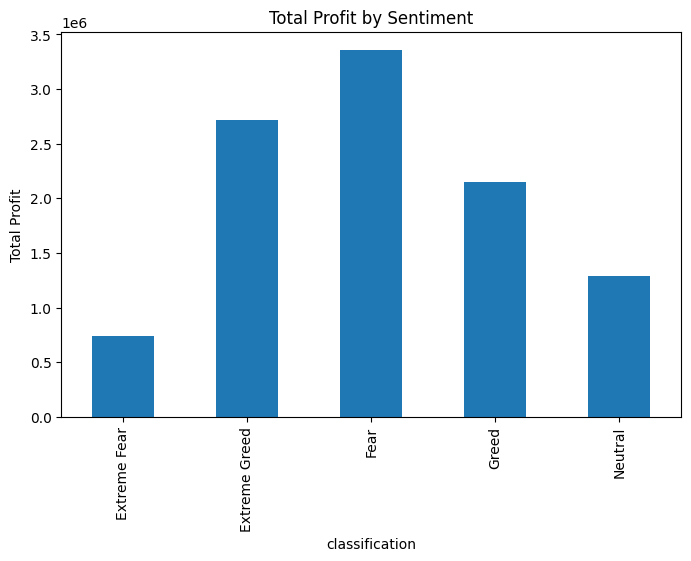

In [17]:
total_profit = df.groupby(
    'classification'
)['Closed PnL'].sum()
print(total_profit)
total_profit.plot(
    kind='bar',
    figsize=(8,5)
)
plt.title("Total Profit by Sentiment")
plt.ylabel("Total Profit")
plt.savefig('../images/total_profit_sentiment.png', bbox_inches='tight')
plt.show()

In [18]:
df['Win'] = df['Closed PnL'] > 0
win_rate = df.groupby(
    'classification'
)['Win'].mean() * 100
print(win_rate)

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: Win, dtype: float64


In [19]:
df.groupby(
    'classification'
)['Size USD'].mean().sort_values(ascending=False)

,Size USD
classification,
Fear,7816.109931
Greed,5736.884375
Extreme Fear,5349.731843
Neutral,4782.732661
Extreme Greed,3112.251565


classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64


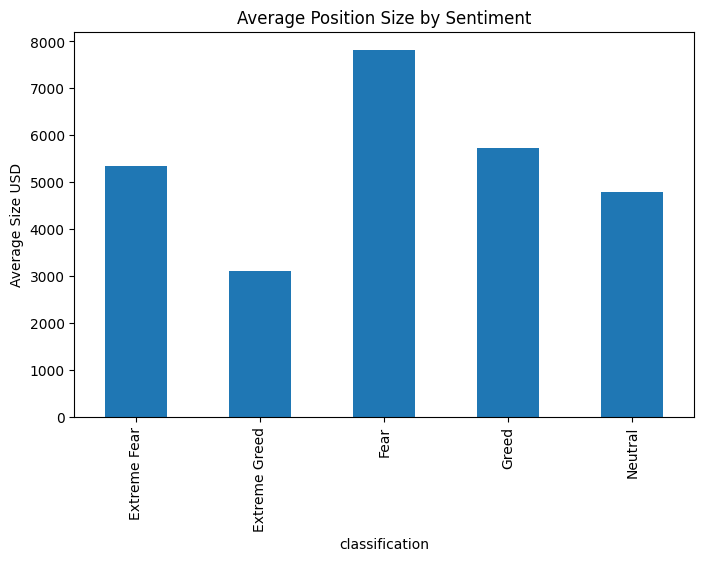

In [20]:
position_size = df.groupby(
    'classification'
)['Size USD'].mean()
print(position_size)
position_size.plot(
    kind='bar',
    figsize=(8,5)
)
plt.title('Average Position Size by Sentiment')
plt.ylabel('Average Size USD')
plt.savefig('../images/average_position_size_sentiment.png', bbox_inches='tight')
plt.show()

In [21]:
top_traders = df.groupby(
    'Account'
)['Closed PnL'].sum()

top10 = top_traders.sort_values(
    ascending=False
).head(10)

print(top10)

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    3.605395e+05
Name: Closed PnL, dtype: float64


In [22]:
coin_profit = df.groupby(
    'Coin'
)['Closed PnL'].sum()

print(
    coin_profit.sort_values(
        ascending=False
    ).head(10)
)

Coin
@107       2.783913e+06
HYPE       1.948485e+06
SOL        1.639556e+06
ETH        1.319979e+06
BTC        8.680447e+05
MELANIA    3.903511e+05
ENA        2.173295e+05
SUI        1.992688e+05
ZRO        1.837778e+05
DOGE       1.475432e+05
Name: Closed PnL, dtype: float64


In [23]:
sentiment_summary = df.groupby('classification').agg({
    'Closed PnL':['mean','sum'],
    'Size USD':'mean',
    'Win':'mean'
})

print(sentiment_summary)

               Closed PnL                   Size USD       Win
                     mean           sum         mean      mean
classification                                                
Extreme Fear    34.537862  7.391102e+05  5349.731843  0.370607
Extreme Greed   67.892861  2.715171e+06  3112.251565  0.464943
Fear            54.290400  3.357155e+06  7816.109931  0.420768
Greed           42.743559  2.150129e+06  5736.884375  0.384828
Neutral         34.307718  1.292921e+06  4782.732661  0.396991


In [26]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['sentiment_encoded'] = le.fit_transform(
    df['classification']
)

df['side_encoded'] = le.fit_transform(
    df['Side']
)
features = [
    'sentiment_encoded',
    'Size USD',
    'side_encoded'
]

X = df[features]
y = df['Closed PnL']
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False,
    inplace=True
)

print(importance)

             Feature  Importance
1           Size USD    0.868302
0  sentiment_encoded    0.104955
2       side_encoded    0.026743


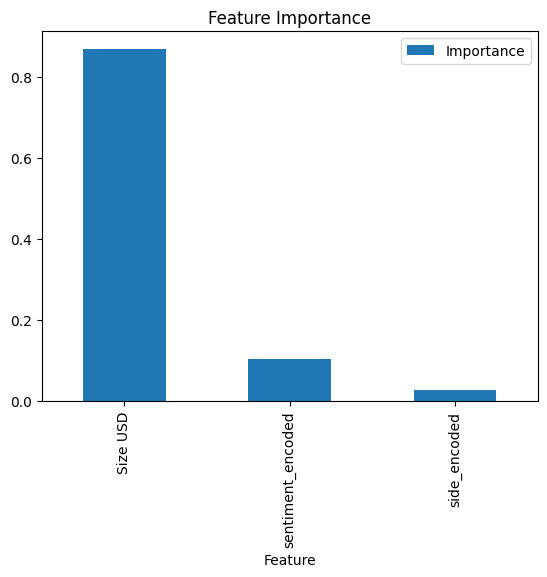

In [27]:
importance.plot(
    x='Feature',
    y='Importance',
    kind='bar'
)

plt.title("Feature Importance")
plt.savefig('../images/feature_importance.png', bbox_inches='tight')
plt.show()